# Data Science Practice
* In this jupyter notebook, I will try to analyze E-commerce data. It will be a good practice for me to improve my data science skills.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
data = pd.read_csv("data.csv",encoding = "latin5")
pd.set_option("display.max_columns",None)
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Exploratory Data Analysis

In [3]:
data.shape

(541909, 8)

In [4]:
data.ndim

2

In [5]:
data.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [6]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
data["total_price"] = data["UnitPrice"]*data["Quantity"]
data["total_price"]

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: total_price, Length: 541909, dtype: float64

In [8]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
total_price           float64
dtype: object

In [9]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
data["Year"] = data["InvoiceDate"].dt.year
data["Month"] = data["InvoiceDate"].dt.month
data["Day"] = data["InvoiceDate"].dt.day
data["Day_name"] = data["InvoiceDate"].dt.day_name()
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Year,Month,Day,Day_name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday


In [11]:
data["Year"].unique()

array([2010, 2011], dtype=int32)

In [12]:
for col in data.columns:
    print(f" Column : {col}")
    print(f" Number of unique value : {data[col].nunique()}")

 Column : InvoiceNo
 Number of unique value : 25900
 Column : StockCode
 Number of unique value : 4070
 Column : Description
 Number of unique value : 4223
 Column : Quantity
 Number of unique value : 722
 Column : InvoiceDate
 Number of unique value : 23260
 Column : UnitPrice
 Number of unique value : 1630
 Column : CustomerID
 Number of unique value : 4372
 Column : Country
 Number of unique value : 38
 Column : total_price
 Number of unique value : 6204
 Column : Year
 Number of unique value : 2
 Column : Month
 Number of unique value : 12
 Column : Day
 Number of unique value : 31
 Column : Day_name
 Number of unique value : 6


## Missing Value

In [13]:
for column in data.columns:
    print(f" Column : {column}")
    print(data[column].isnull().sum())
    print()

 Column : InvoiceNo
0

 Column : StockCode
0

 Column : Description
1454

 Column : Quantity
0

 Column : InvoiceDate
0

 Column : UnitPrice
0

 Column : CustomerID
135080

 Column : Country
0

 Column : total_price
0

 Column : Year
0

 Column : Month
0

 Column : Day
0

 Column : Day_name
0



## Numeric Variables

In [14]:
numeric_var = data.select_dtypes(include = ["int","float"]).columns
numeric_var

Index(['Quantity', 'UnitPrice', 'CustomerID', 'total_price', 'Year', 'Month',
       'Day'],
      dtype='object')

* We don't need to analyze every numeric column because it could mean nothing like CustomerId

## Categorical Variables

In [19]:
categorical_var = data.select_dtypes(exclude = ["int","float"]).columns
categorical_var

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country',
       'Day_name'],
      dtype='object')

## Data Visualization And Storytelling

In [37]:
country_customer_report = data.groupby("Country").agg(
    total_price = ("total_price","mean"),
    customer_count = ("CustomerID","count")
).round(2).reset_index()

country_customer_report = country_customer_report.sort_values(by = "total_price",ascending = False)
country_customer_report

,Country,total_price,customer_count
24,Netherlands,120.06,2371
0,Australia,108.88,1259
20,Japan,98.72,358
32,Sweden,79.21,462
9,Denmark,48.25,389
22,Lithuania,47.46,35
30,Singapore,39.83,229
21,Lebanon,37.64,45
4,Brazil,35.74,32
16,Hong Kong,35.13,0


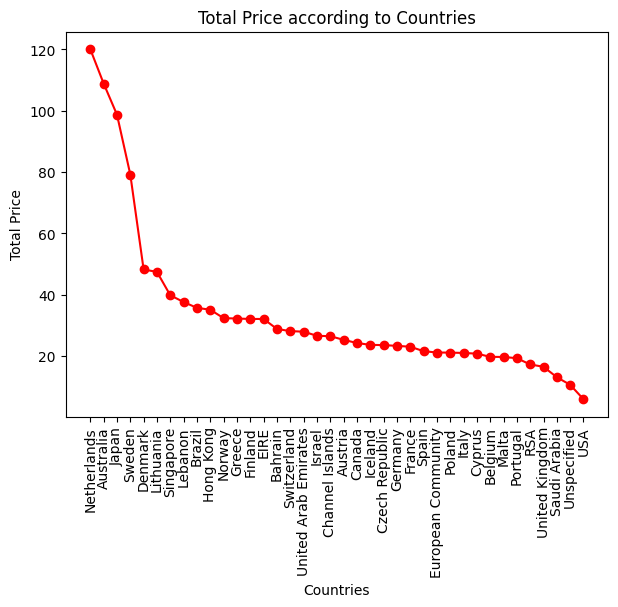

In [38]:
plt.figure(figsize=(7,5))
plt.plot(country_customer_report["Country"],country_customer_report["total_price"],c = "red",marker = "o")
plt.title("Total Price according to Countries")
plt.ylabel("Total Price")
plt.xticks(rotation = 90)
plt.xlabel("Countries")
plt.show()

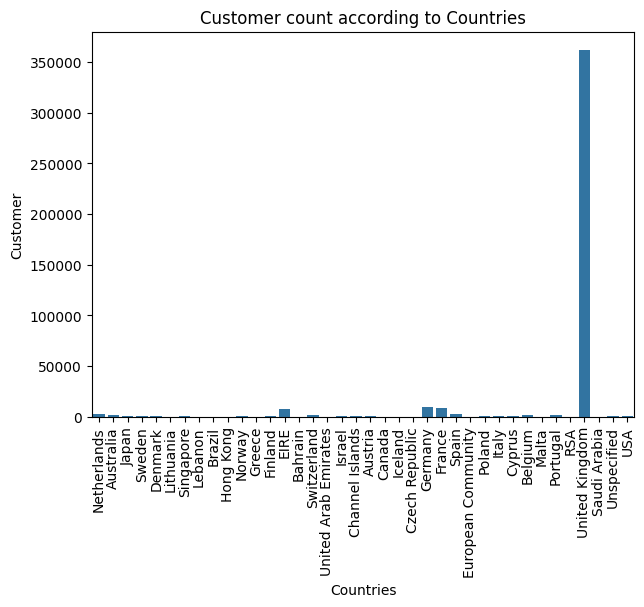

In [42]:
plt.figure(figsize=(7,5))
sns.barplot(data =country_customer_report,x = "Country",y  = "customer_count")
plt.title("Customer count according to Countries")
plt.ylabel("Customer")
plt.xticks(rotation = 90)
plt.xlabel("Countries")
plt.show()

In [44]:
# Orders according to month
month_order_report = data.groupby("Month").agg(
    total_price = ("total_price","sum")).reset_index()
month_order_report

,Month,total_price
0,1,560000.260
1,2,498062.650
2,3,683267.080
3,4,493207.121
4,5,723333.510
5,6,691123.120
6,7,681300.111
7,8,682680.510
8,9,1019687.622
9,10,1070704.670


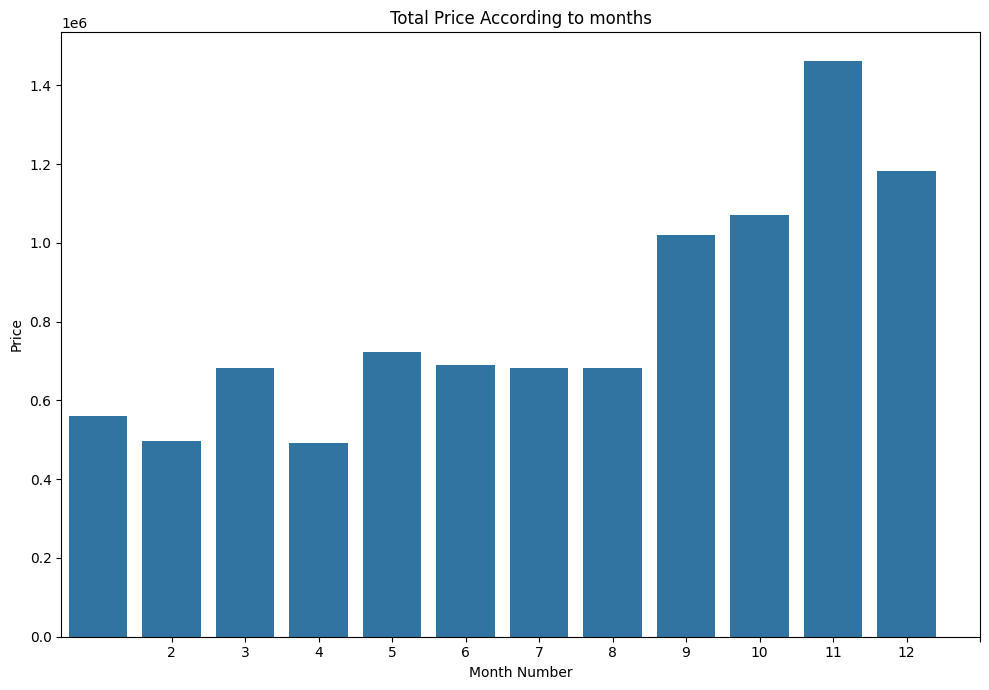

In [45]:
plt.figure(figsize = (10,7))
sns.barplot(data = month_order_report,x = "Month",y = "total_price")
plt.title("Total Price According to months")
plt.xticks(month_order_report["Month"])
plt.xlabel("Month Number")
plt.ylabel("Price")
plt.tight_layout()
plt.show()